In [1]:
import pandas as pd   #Usamos para ler a planilha, organizar colunas, filtrar dados e calcular médias.
import numpy as np    #Ela trabalha com números, cálculos matemáticos e listas numéricas.

import matplotlib.pyplot as plt  #Usamos para fazer gráficos de barras, linhas, dispersão e o gráfico do cotovelo.
import seaborn as sns   #deixa os gráficos mais bonitos e fáceis de visualizar.

from sklearn.cluster import KMeans  #usado para separar os Estados em grupos parecidos, chamados de clusters.
from sklearn.preprocessing import StandardScaler   #serve para padronizar os dados, deixando tudo na mesma escala antes de aplicar o K-Means.
from sklearn.metrics import silhouette_score   #mede se os grupos criados pelo K-Means ficaram bons ou não.

from mlxtend.frequent_patterns import apriori   #serve para encontrar padrões frequentes nos dados.
from mlxtend.frequent_patterns import association_rules #cria as regras de associação a partir dos padrões encontrados pelo Apriori.
from mlxtend.preprocessing import TransactionEncoder #transforma os dados em um formato que o Apriori consegue entender.

In [2]:
arquivo = 'domicilios num moradores brasil.xlsx'
                                        # esse bloco cria a variável "arquivo" e guarda o nome do arquivo Excel.
df = pd.read_excel(arquivo)             # nessa linha o pandas abre o excel e guarda os dados.

print(df.head())

                Ano       2022         2022       2022.1       2022.2  \
0         Município  1 morador  2 moradores  3 moradores  4 moradores   
1  Porto Velho (RO)       12.5          8.4          9.3          7.8   
2   Rio Branco (AC)       10.8          6.5          5.5          5.9   
3       Manaus (AM)       10.9          6.6          5.8          5.8   
4    Boa Vista (RR)       16.9          9.5          7.8          5.9   

        2022.3               2022.4       2025         2025       2025.1  \
0  5 moradores  6 moradores ou mais  1 morador  2 moradores  3 moradores   
1         13.3                 14.5       14.7            7          6.3   
2          9.6                 10.9        7.6          5.8          4.8   
3          9.6                  7.5        9.5            6          5.1   
4         10.4                 10.8        9.6          7.5          7.8   

        2025.2       2025.3               2025.4  
0  4 moradores  5 moradores  6 moradores ou mais  
1 

In [3]:
print(df.columns)

Index([   'Ano',   '2022',     2022, '2022.1', '2022.2', '2022.3', '2022.4',
         '2025',     2025, '2025.1', '2025.2', '2025.3', '2025.4'],
      dtype='object')


In [4]:
print(df.head(10))

                Ano       2022         2022       2022.1       2022.2  \
0         Município  1 morador  2 moradores  3 moradores  4 moradores   
1  Porto Velho (RO)       12.5          8.4          9.3          7.8   
2   Rio Branco (AC)       10.8          6.5          5.5          5.9   
3       Manaus (AM)       10.9          6.6          5.8          5.8   
4    Boa Vista (RR)       16.9          9.5          7.8          5.9   
5        Belém (PA)       11.8          8.5          7.1          6.8   
6       Macapá (AP)       17.7           11          7.1          8.7   
7       Palmas (TO)       15.6         14.1          9.7           10   
8     São Luís (MA)       12.9          7.8          7.5            8   
9     Teresina (PI)       18.4            9          7.6          9.1   

        2022.3               2022.4       2025         2025       2025.1  \
0  5 moradores  6 moradores ou mais  1 morador  2 moradores  3 moradores   
1         13.3                 14.5       14

In [5]:
# Procurar Estado de São Paulo

sp = df[df['Ano'].str.contains('(SP)', regex=False, na=False)]

print(sp)

               Ano 2022 2022 2022.1 2022.2 2022.3 2022.4 2025 2025 2025.1  \
20  São Paulo (SP)  6.4  4.8    3.8    5.1    9.1   12.5  6.9  4.6      4   

   2025.2 2025.3 2025.4  
20    5.3     13   16.3  


In [6]:
print(df['Ano'].head(50))

0               Município
1        Porto Velho (RO)
2         Rio Branco (AC)
3             Manaus (AM)
4          Boa Vista (RR)
5              Belém (PA)
6             Macapá (AP)
7             Palmas (TO)
8           São Luís (MA)
9           Teresina (PI)
10         Fortaleza (CE)
11             Natal (RN)
12       João Pessoa (PB)
13            Recife (PE)
14            Maceió (AL)
15           Aracaju (SE)
16          Salvador (BA)
17    Belo Horizonte (MG)
18           Vitória (ES)
19    Rio de Janeiro (RJ)
20         São Paulo (SP)
21          Curitiba (PR)
22     Florianópolis (SC)
23      Porto Alegre (RS)
24      Campo Grande (MS)
25            Cuiabá (MT)
26           Goiânia (GO)
27          Brasília (DF)
Name: Ano, dtype: str


In [7]:
# Ajustar nomes das colunas

df.columns = [
    'Estados',
    '2022_1_morador',
    '2022_2_moradores',
    '2022_3_moradores',
    '2022_4_moradores',
    '2022_5_moradores',
    '2022_6_ou_mais',
    '2025_1_morador',
    '2025_2_moradores',
    '2025_3_moradores',
    '2025_4_moradores',
    '2025_5_moradores',
    '2025_6_ou_mais'
]

print(df.head())

            Estados 2022_1_morador 2022_2_moradores 2022_3_moradores  \
0         Município      1 morador      2 moradores      3 moradores   
1  Porto Velho (RO)           12.5              8.4              9.3   
2   Rio Branco (AC)           10.8              6.5              5.5   
3       Manaus (AM)           10.9              6.6              5.8   
4    Boa Vista (RR)           16.9              9.5              7.8   

  2022_4_moradores 2022_5_moradores       2022_6_ou_mais 2025_1_morador  \
0      4 moradores      5 moradores  6 moradores ou mais      1 morador   
1              7.8             13.3                 14.5           14.7   
2              5.9              9.6                 10.9            7.6   
3              5.8              9.6                  7.5            9.5   
4              5.9             10.4                 10.8            9.6   

  2025_2_moradores 2025_3_moradores 2025_4_moradores 2025_5_moradores  \
0      2 moradores      3 moradores      4 

In [8]:
# Remove primeira linha da tabela.

df = df.iloc[1:]

# Resetar índices

df.reset_index(drop=True, inplace=True)

print(df.head())

            Estados 2022_1_morador 2022_2_moradores 2022_3_moradores  \
0  Porto Velho (RO)           12.5              8.4              9.3   
1   Rio Branco (AC)           10.8              6.5              5.5   
2       Manaus (AM)           10.9              6.6              5.8   
3    Boa Vista (RR)           16.9              9.5              7.8   
4        Belém (PA)           11.8              8.5              7.1   

  2022_4_moradores 2022_5_moradores 2022_6_ou_mais 2025_1_morador  \
0              7.8             13.3           14.5           14.7   
1              5.9              9.6           10.9            7.6   
2              5.8              9.6            7.5            9.5   
3              5.9             10.4           10.8            9.6   
4              6.8             10.9           13.8            9.8   

  2025_2_moradores 2025_3_moradores 2025_4_moradores 2025_5_moradores  \
0                7              6.3              7.9             16.3   
1     

In [9]:
# transformou os dados da planilha em números porque a primeira coluna é texto.

colunas_numericas = df.columns[1:]  # Converte para número e pega da posição 1 até o final

for coluna in colunas_numericas:        
    df[coluna] = pd.to_numeric(df[coluna])

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Estados           27 non-null     str    
 1   2022_1_morador    27 non-null     float64
 2   2022_2_moradores  27 non-null     float64
 3   2022_3_moradores  27 non-null     float64
 4   2022_4_moradores  27 non-null     float64
 5   2022_5_moradores  27 non-null     float64
 6   2022_6_ou_mais    27 non-null     float64
 7   2025_1_morador    27 non-null     float64
 8   2025_2_moradores  27 non-null     float64
 9   2025_3_moradores  27 non-null     float64
 10  2025_4_moradores  27 non-null     float64
 11  2025_5_moradores  27 non-null     float64
 12  2025_6_ou_mais    27 non-null     float64
dtypes: float64(12), str(1)
memory usage: 3.2 KB
None


In [10]:
print(df.head())               # por padrão mostra as 5 primeiras linhas da tabela.

            Estados  2022_1_morador  2022_2_moradores  2022_3_moradores  \
0  Porto Velho (RO)            12.5               8.4               9.3   
1   Rio Branco (AC)            10.8               6.5               5.5   
2       Manaus (AM)            10.9               6.6               5.8   
3    Boa Vista (RR)            16.9               9.5               7.8   
4        Belém (PA)            11.8               8.5               7.1   

   2022_4_moradores  2022_5_moradores  2022_6_ou_mais  2025_1_morador  \
0               7.8              13.3            14.5            14.7   
1               5.9               9.6            10.9             7.6   
2               5.8               9.6             7.5             9.5   
3               5.9              10.4            10.8             9.6   
4               6.8              10.9            13.8             9.8   

   2025_2_moradores  2025_3_moradores  2025_4_moradores  2025_5_moradores  \
0               7.0              

In [11]:
print(df.describe())    # mostra o resumo estatistico da tabela, como média, desvio padrão, mínimo e máximo.

       2022_1_morador  2022_2_moradores  2022_3_moradores  2022_4_moradores  \
count       27.000000         27.000000         27.000000         27.000000   
mean        11.322222          7.644444          6.588889          7.433333   
std          3.289416          2.420320          1.532804          1.898785   
min          5.100000          3.600000          3.500000          4.300000   
25%          9.500000          6.500000          5.500000          5.900000   
50%         11.600000          6.700000          7.100000          7.200000   
75%         12.750000          8.800000          7.550000          8.550000   
max         18.400000         14.100000          9.700000         11.300000   

       2022_5_moradores  2022_6_ou_mais  2025_1_morador  2025_2_moradores  \
count         27.000000       27.000000       27.000000         27.000000   
mean          12.937037       17.785185        9.322222          6.377778   
std            3.600764        5.890912        2.477954  

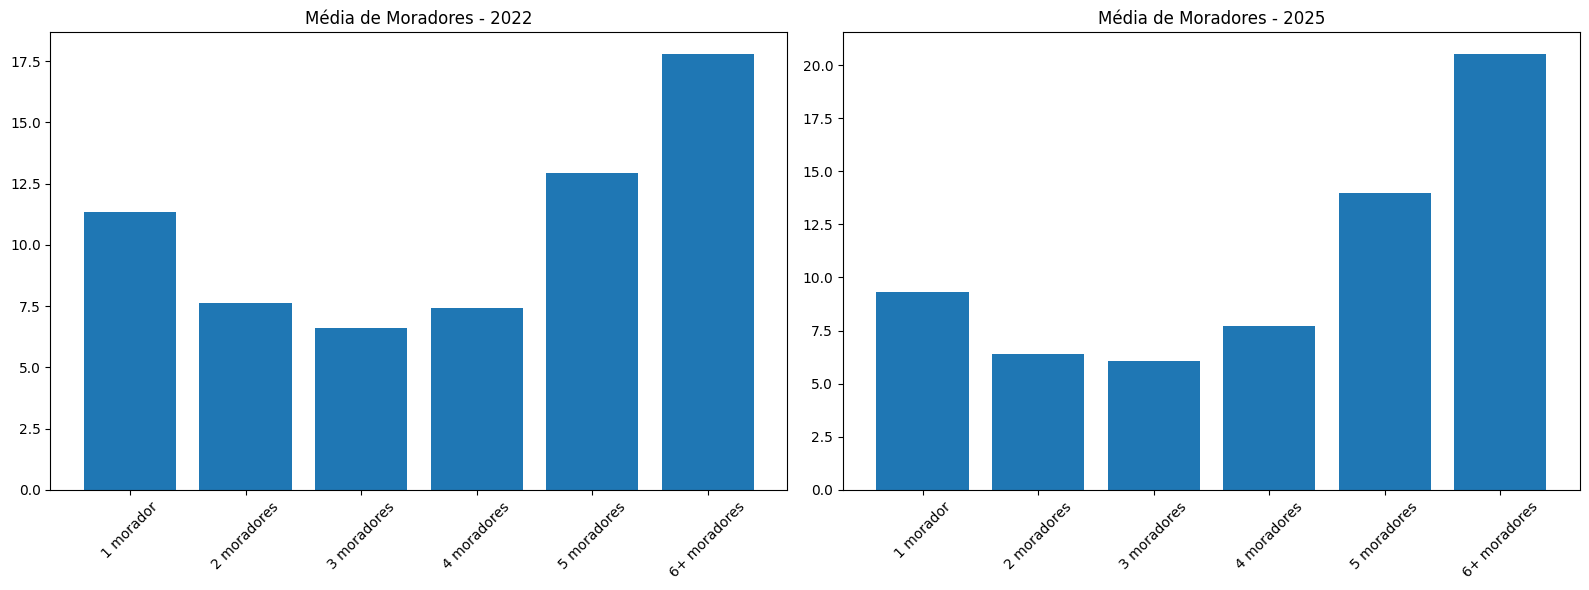

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))
                            # criados dois gráficos de barras lado a lado para comparar as médias de moradores
# 2022
medias_2022 = [
    df['2022_1_morador'].mean(),
    df['2022_2_moradores'].mean(),
    df['2022_3_moradores'].mean(),
    df['2022_4_moradores'].mean(),
    df['2022_5_moradores'].mean(),
    df['2022_6_ou_mais'].mean()
]

categorias = [
    '1 morador',
    '2 moradores',
    '3 moradores',
    '4 moradores',
    '5 moradores',
    '6+ moradores'
]

axes[0].bar(categorias, medias_2022)
axes[0].set_title('Média de Moradores - 2022')
axes[0].tick_params(axis='x', rotation=45)

# 2025
medias_2025 = [
    df['2025_1_morador'].mean(),
    df['2025_2_moradores'].mean(),
    df['2025_3_moradores'].mean(),
    df['2025_4_moradores'].mean(),
    df['2025_5_moradores'].mean(),
    df['2025_6_ou_mais'].mean()
]

axes[1].bar(categorias, medias_2025)
axes[1].set_title('Média de Moradores - 2025')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [14]:
X = df[colunas_numericas]        # seleciona apenas as colunas numéricas para o K-Means

In [15]:
scaler = StandardScaler()   # ferramenta do Scikit-Learn que ajusta os números para uma escala parecida.

X_padronizado = scaler.fit_transform(X)

C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_

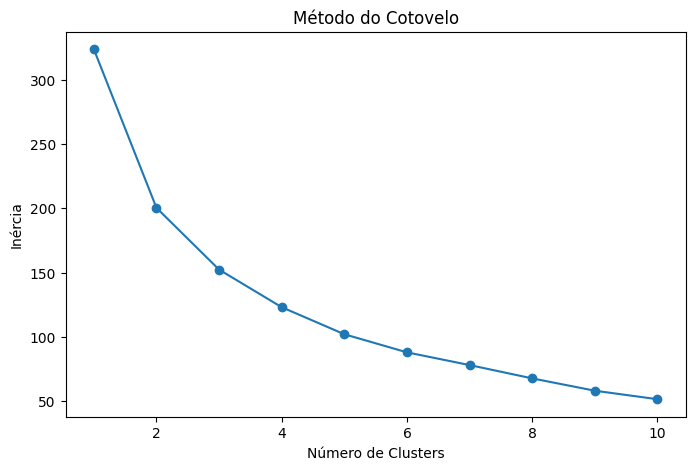

In [16]:
inercias = []                        # A inércia mede o quão “organizados” os grupos ficaram.      
                                     # serve para descobrir quantos grupos (clusters) o K-Means deve usar.
                                     # Criao gráfico do Método do Cotovelo.

for k in range(1,11):
    modelo = KMeans(                              # prepara o algoritmo k-means para testar.
        n_clusters=k,                             # quantos grupos serão testados
        random_state=42,                          # mantém os resultados consistentes em cada execução
        n_init=10                                 # testa 10 vezes e pega o melhor resultado
    )

    modelo.fit(X_padronizado)                     # O algoritmo analisa os dados padronizados.

    inercias.append(modelo.inertia_)              #  a inércia mede o quão “organizados” os grupos ficaram.

plt.figure(figsize=(8,5))                         # tamanho do gráfico do Método do Cotovelo

plt.plot(range(1,11), inercias, marker='o')       # testa 10lusters (a curva do Método do Cotovelo).

plt.xlabel('Número de Clusters')
plt.ylabel('Inércia')
                                                # "escolhido o valor de 3 clusters.”
plt.title('Método do Cotovelo')

plt.show()

C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_

Silhouette Score com 3 clusters: 0.2712398309140975


C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


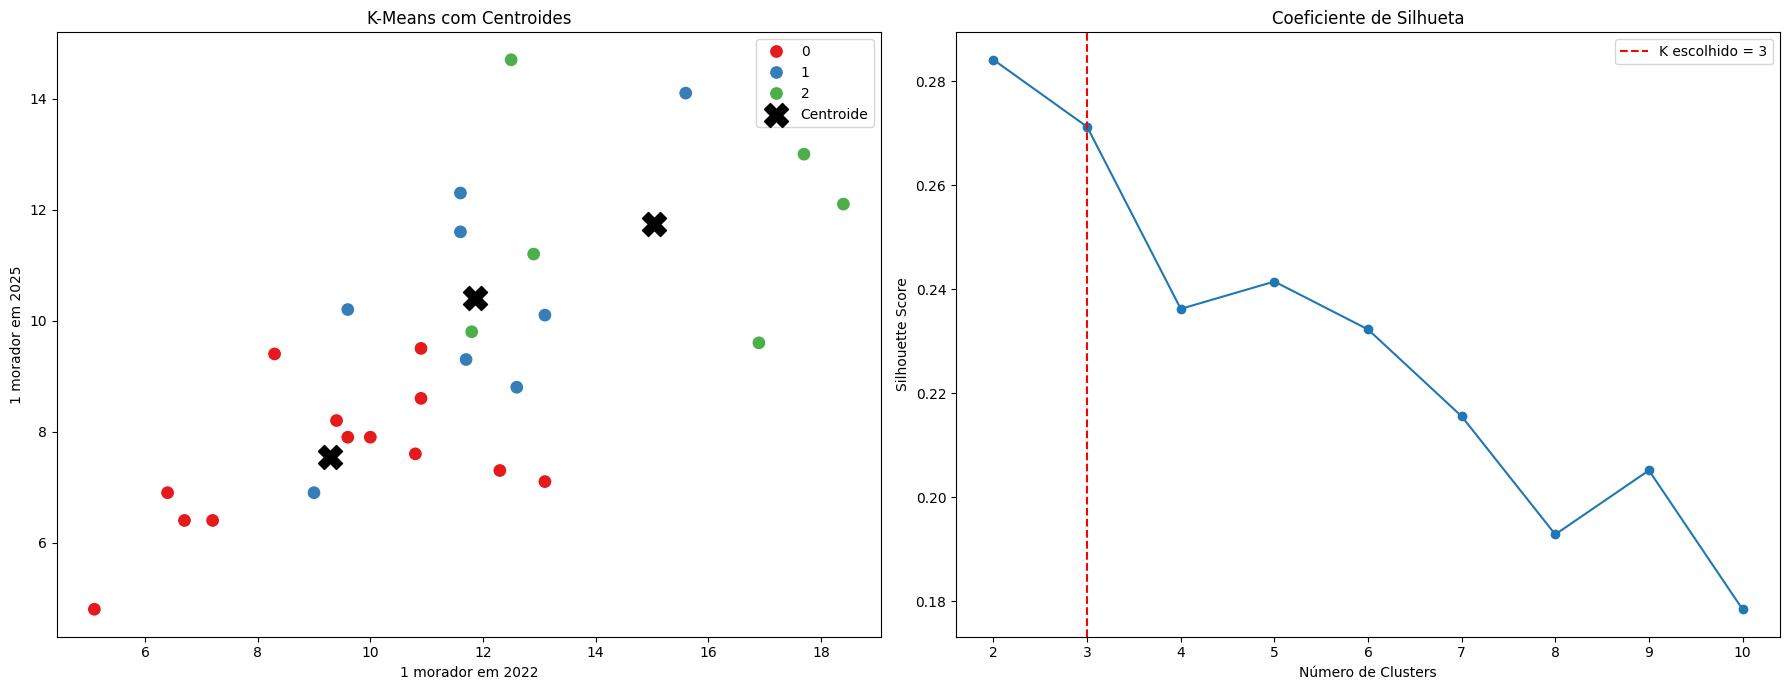

In [18]:
# =========================
# K-MEANS COM CENTROIDES + SILHUETA EM LINHA
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Selecionar apenas colunas numéricas
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Remover colunas criadas anteriormente, se existirem
colunas_numericas = colunas_numericas.drop(
    ['Cluster', 'Silhueta'], 
    errors='ignore'
)

X = df[colunas_numericas]

# Padronizar dados
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

# Aplicar K-Means com 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_padronizado)

score = silhouette_score(X_padronizado, df['Cluster'])

print("Silhouette Score com 3 clusters:", score)

# Calcular centroides
centroides_padronizados = kmeans.cluster_centers_
centroides = scaler.inverse_transform(centroides_padronizados)

centroides_df = pd.DataFrame(
    centroides,
    columns=colunas_numericas
)

# Calcular silhueta para vários valores de K
silhuetas = []

valores_k = range(2, 11)

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    clusters = modelo.fit_predict(X_padronizado)
    
    silhueta = silhouette_score(
        X_padronizado,
        clusters
    )
    
    silhuetas.append(silhueta)

# =========================
# GRÁFICOS LADO A LADO
# =========================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# =========================
# GRÁFICO 1 - K-MEANS COM CENTROIDES
# =========================

sns.scatterplot(
    data=df,
    x='2022_1_morador',
    y='2025_1_morador',
    hue='Cluster',
    palette='Set1',
    s=100,
    ax=axes[0]
)

axes[0].scatter(
    centroides_df['2022_1_morador'],
    centroides_df['2025_1_morador'],
    marker='X',
    s=300,
    color='black',
    label='Centroide'
)

axes[0].set_title('K-Means com Centroides')
axes[0].set_xlabel('1 morador em 2022')
axes[0].set_ylabel('1 morador em 2025')
axes[0].legend()

# =========================
# GRÁFICO 2 - SILHUETA EM FORMATO DE LINHA
# =========================

axes[1].plot(
    valores_k,
    silhuetas,
    marker='o'
)

axes[1].axvline(
    x=3,
    color='red',
    linestyle='--',
    label='K escolhido = 3'
)

axes[1].set_title('Coeficiente de Silhueta')
axes[1].set_xlabel('Número de Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# =========================
# APRIORI - FUNÇÃO
# =========================

def rodar_apriori(base, nome_base): 
    dados = base.copy()    # a função recebe a base/tabela e cria uma copia para não alterar os dados originais.
    
    for coluna in colunas_numericas:
        media = dados[coluna].mean()                           # faz a média da coluna.
        dados[coluna] = dados[coluna].apply(
            lambda x: f'{coluna}_Alto' if x >= media else f'{coluna}_Baixo'      # pra cada valor da coluna.
        )                                                                   # transf. numeros em categorias:
                                                                                       # alto ou baixo.
    transacoes = dados[colunas_numericas].values.tolist()  # Transforma a tabela em lista de transações.
    
    te = TransactionEncoder()       # Cria o codificador de transações, transf.alto e baixo em true ou false.
    te_array = te.fit(transacoes).transform(transacoes) # Aqui os dados são convertidos para o formato do Apriori.
    basket = pd.DataFrame(te_array, columns=te.columns_)  # Cria uma nova tabela organizada.Agora o Apriori
                                                                # consegue ler os dados.
    
    frequentes = apriori(         # Aqui o algoritmo Apriori é executado.
        basket,                   # procura padrões frequentes.
        min_support=0.2,     # Significa só mostrar padrões que aparecem em pelo menos 20% dos Estados.  
        use_colnames=True     
    )
    
    regras = association_rules(    # as regras de associação são criadas.
        frequentes,
        metric='confidence',       # confiança como critério principal.
        min_threshold=0.7          # Significa mostrar apenas regras com confiança maior que 70%.
    )
    
    regras = regras.sort_values(by='lift', ascending=False) # Organiza da regra mais forte para a mais fraca.
    regras['Base'] = nome_base                              # Lift mede a força da associação,
                                                            # Quanto maior mais forte a relação.
    return regras

In [20]:
# Filtrar apenas São Paulo nessa função.

sp = df[df['Estados'].str.contains('(SP)', regex=False)]  # regex significa tratar (SP) como texto normal.

print(sp)

           Estados  2022_1_morador  2022_2_moradores  2022_3_moradores  \
19  São Paulo (SP)             6.4               4.8               3.8   

    2022_4_moradores  2022_5_moradores  2022_6_ou_mais  2025_1_morador  \
19               5.1               9.1            12.5             6.9   

    2025_2_moradores  2025_3_moradores  2025_4_moradores  2025_5_moradores  \
19               4.6               4.0               5.3              13.0   

    2025_6_ou_mais  Cluster  
19            16.3        0  


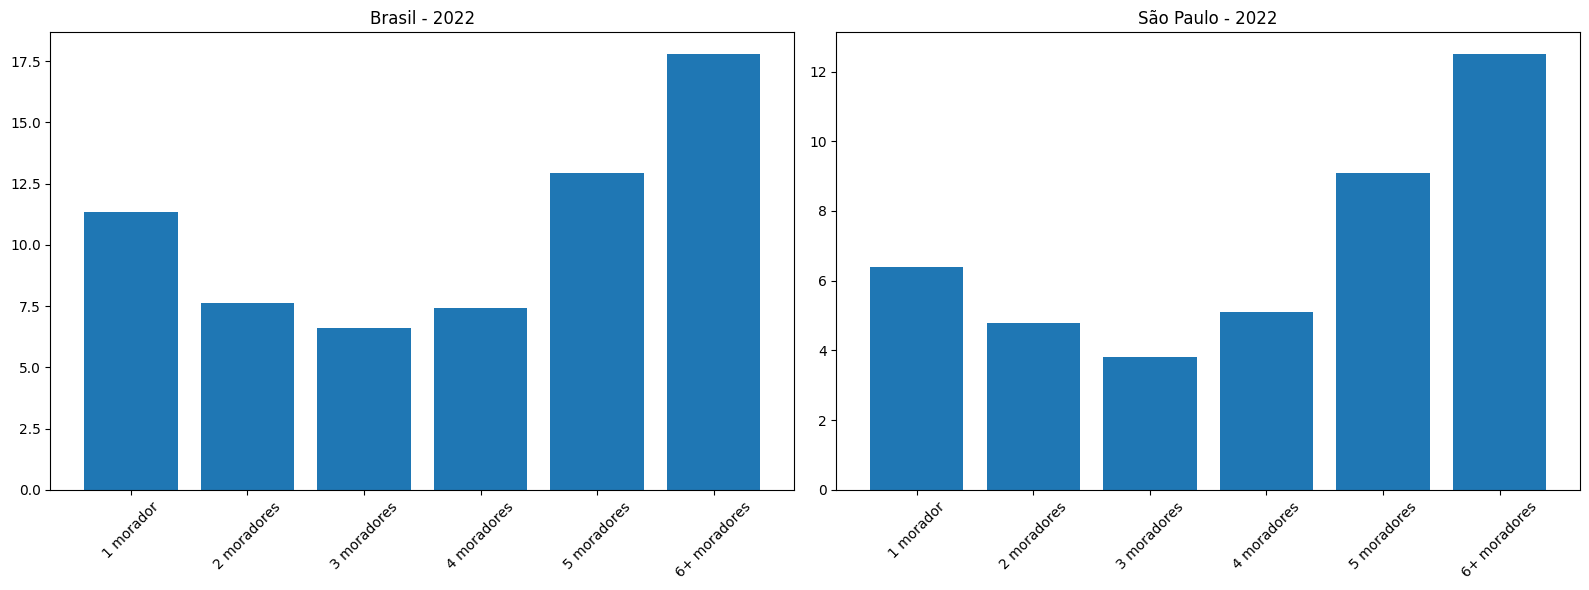

In [21]:
# Médias Brasil

brasil_2022 = [
    df['2022_1_morador'].mean(),
    df['2022_2_moradores'].mean(),
    df['2022_3_moradores'].mean(),
    df['2022_4_moradores'].mean(),
    df['2022_5_moradores'].mean(),
    df['2022_6_ou_mais'].mean()
]

# Dados São Paulo

sp_2022 = [
    sp['2022_1_morador'].mean(),
    sp['2022_2_moradores'].mean(),
    sp['2022_3_moradores'].mean(),
    sp['2022_4_moradores'].mean(),
    sp['2022_5_moradores'].mean(),
    sp['2022_6_ou_mais'].mean()
]

categorias = [
    '1 morador',
    '2 moradores',
    '3 moradores',
    '4 moradores',
    '5 moradores',
    '6+ moradores'
]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Brasil
axes[0].bar(categorias, brasil_2022)        # eixo "y" representa a média de moradores nos Estados por categoria.
axes[0].set_title('Brasil - 2022')
axes[0].tick_params(axis='x', rotation=45)   # eixo "x", quantidade de moradores. 
                                            # rotation=45 é girar os nomes em 45 graus eixo "x".

# São Paulo
axes[1].bar(categorias, sp_2022)
axes[1].set_title('São Paulo - 2022')
axes[1].tick_params(axis='x', rotation=45)              # No gráfico abaixo, no Brasil
                                    # em média, cerca de 11% dos domicílios analisados possuem apenas 1 morador.
plt.tight_layout()                      # e em São Paulo, cerca de 6% dos domicílios possuem apenas 1 morador.
plt.show()

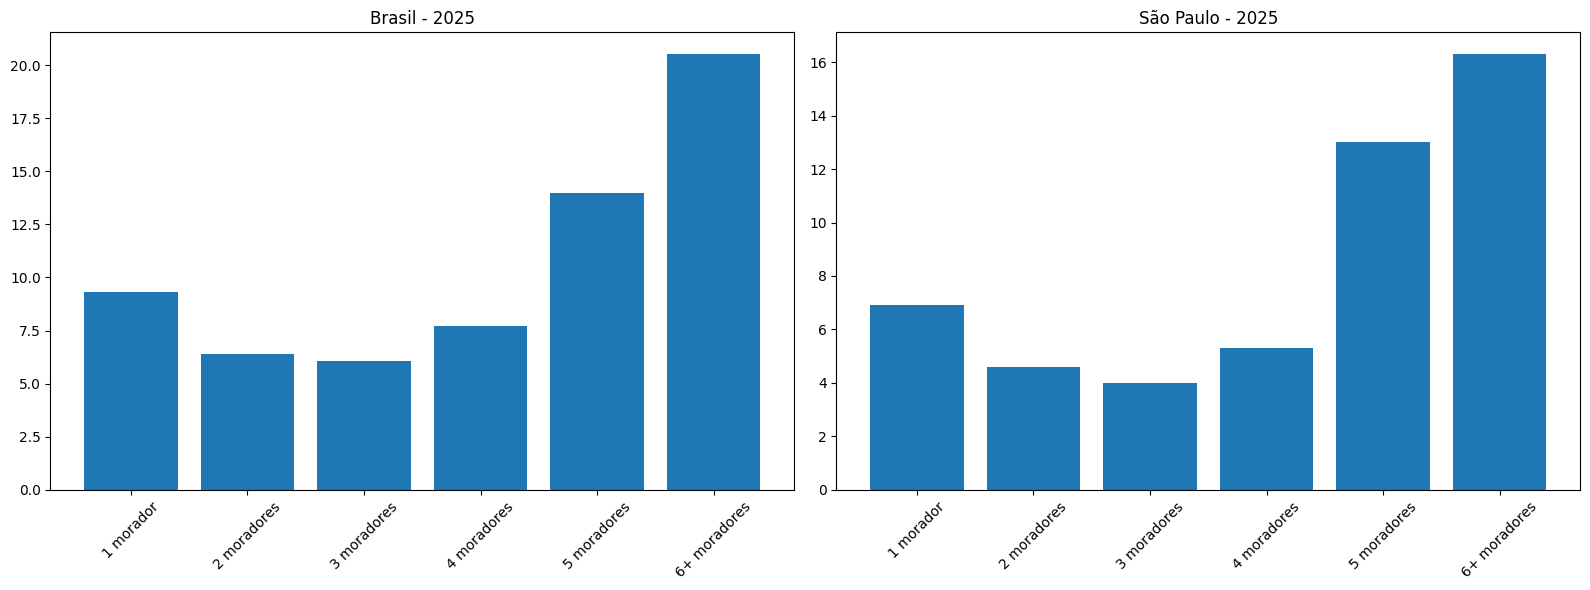

In [22]:
# Médias Brasil

brasil_2025 = [
    df['2025_1_morador'].mean(),
    df['2025_2_moradores'].mean(),
    df['2025_3_moradores'].mean(),
    df['2025_4_moradores'].mean(),
    df['2025_5_moradores'].mean(),
    df['2025_6_ou_mais'].mean()
]

# Dados São Paulo

sp_2025 = [
    sp['2025_1_morador'].mean(),
    sp['2025_2_moradores'].mean(),
    sp['2025_3_moradores'].mean(),
    sp['2025_4_moradores'].mean(),
    sp['2025_5_moradores'].mean(),
    sp['2025_6_ou_mais'].mean()
]

categorias = [
    '1 morador',
    '2 moradores',
    '3 moradores',
    '4 moradores',
    '5 moradores',
    '6+ moradores'
]

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Brasil
axes[0].bar(categorias, brasil_2025)
axes[0].set_title('Brasil - 2025')
axes[0].tick_params(axis='x', rotation=45)

# São Paulo
axes[1].bar(categorias, sp_2025)
axes[1].set_title('São Paulo - 2025')
axes[1].tick_params(axis='x', rotation=45)      # No gráfico abaixo, no Brasil, aproximadamente 9% dos domicílios
                                                # analisados possuem apenas 1 morador em 2025.
plt.tight_layout()                      # e no Estado de São Paulo, 7% dos domicílios possuem apenas 1 morador.
plt.show()

In [23]:
# =========================
# K-MEANS
# =========================
                            # Foi aqui que os Estados foram agrupados automaticamente.
X = df[colunas_numericas]   # exemplo, 1 morador, 2 moradores, etc. para cada ano.

scaler = StandardScaler()   # Aqui os dados foram padronizados.Os números foram colocados na mesma escala.
X_padronizado = scaler.fit_transform(X)     # evita que uma coluna influencie mais que outra.

kmeans = KMeans(
    n_clusters=3,          # k-means cria 3 grupos/clusters.
    random_state=42,       # mantém o mesmo resultado toda vez que rodar o código.
    n_init=10              # O algoritmo faz 10 tentativas e escolhe a melhor.
)

df['Cluster'] = kmeans.fit_predict(X_padronizado)   # Aqui aconteceu o agrupamento dos Estados.

score = silhouette_score(X_padronizado, df['Cluster'])  # calcula a qualidade dos grupos.

print("Silhouette Score:", score) # Coeficiente de Silhueta: 0.27 Significa separação moderada entre os grupos.
print(df[['Estados', 'Cluster']]) # Mostra cada Estado e o grupo ao qual pertence.

Silhouette Score: 0.2712398309140975
                Estados  Cluster
0      Porto Velho (RO)        2
1       Rio Branco (AC)        0
2           Manaus (AM)        0
3        Boa Vista (RR)        2
4            Belém (PA)        2
5           Macapá (AP)        2
6           Palmas (TO)        1
7         São Luís (MA)        2
8         Teresina (PI)        2
9        Fortaleza (CE)        0
10           Natal (RN)        1
11     João Pessoa (PB)        0
12          Recife (PE)        1
13          Maceió (AL)        0
14         Aracaju (SE)        1
15        Salvador (BA)        1
16  Belo Horizonte (MG)        0
17         Vitória (ES)        1
18  Rio de Janeiro (RJ)        0
19       São Paulo (SP)        0
20        Curitiba (PR)        0
21   Florianópolis (SC)        1
22    Porto Alegre (RS)        0
23    Campo Grande (MS)        0
24          Cuiabá (MT)        1
25         Goiânia (GO)        0
26        Brasília (DF)        0


C:\Users\drubi\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


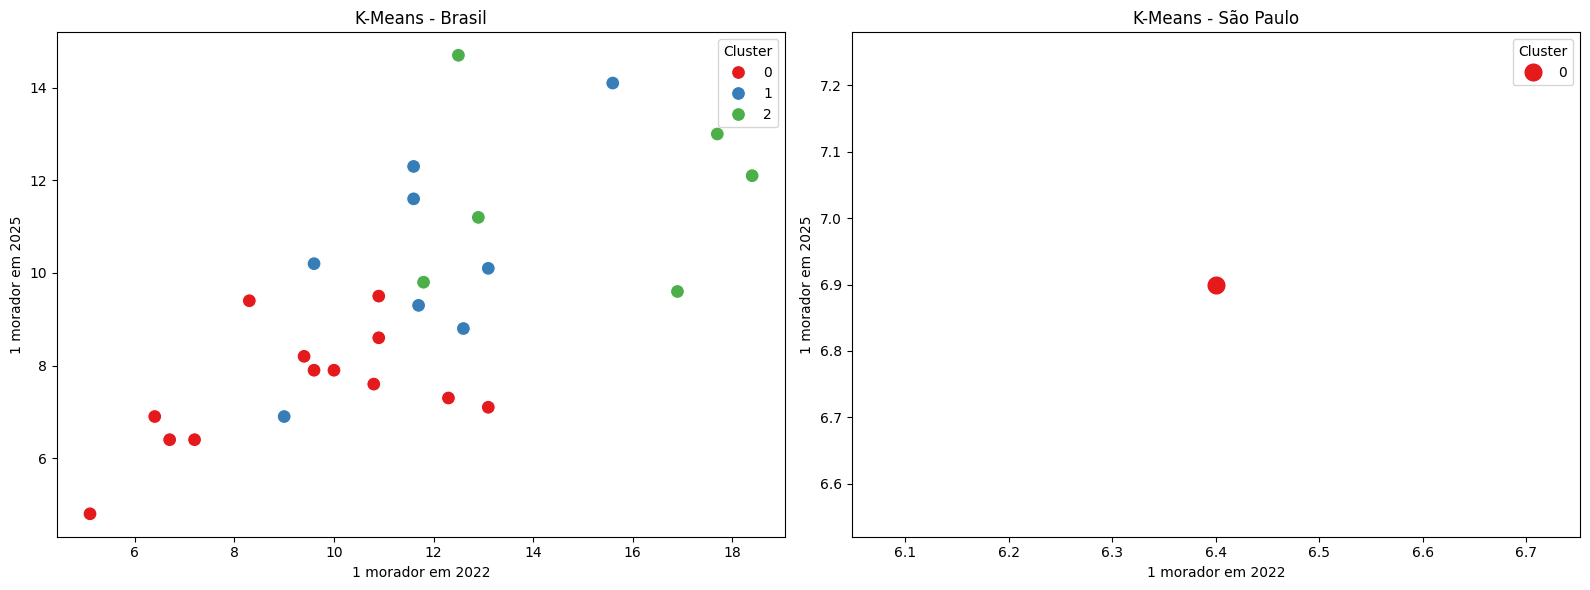

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.scatterplot(
    data=df,
    x='2022_1_morador',
    y='2025_1_morador',
    hue='Cluster',
    palette='Set1',
    s=100,
    ax=axes[0]
)

axes[0].set_title('K-Means - Brasil')       # título no gráfico.
axes[0].set_xlabel('1 morador em 2022')
axes[0].set_ylabel('1 morador em 2025')

sp = df[df['Estados'].str.contains('(SP)', regex=False)]

sns.scatterplot(
    data=sp,
    x='2022_1_morador',
    y='2025_1_morador',
    hue='Cluster',
    palette='Set1',          # paleta de cores para diferenciar os clusters.
    s=200,
    ax=axes[1]
)

axes[1].set_title('K-Means - São Paulo')
axes[1].set_xlabel('1 morador em 2022')
axes[1].set_ylabel('1 morador em 2025')

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# APRIORI                               # parece repetido, mas não é porque os passos internos são iguais;
# =========================             # mas o primeiro bloco CRIA a função;e este, EXECUTA a análise.
apriori_df = df.copy()

for coluna in colunas_numericas:
    media = apriori_df[coluna].mean()
    
    apriori_df[coluna] = apriori_df[coluna].apply(
        lambda x: f'{coluna}_Alto' if x >= media else f'{coluna}_Baixo'
    )

transacoes = apriori_df[colunas_numericas].values.tolist()

te = TransactionEncoder()
te_array = te.fit(transacoes).transform(transacoes)

basket = pd.DataFrame(te_array, columns=te.columns_)

                                     # Resultado abaixo significa aproximadamente que em 22% dos Estados
                                    # com muitos domicílios com 1 morador, também possuem
                                    # poucos domicílios com 6 moradores ou mais (apresentaram esse padrão).
                                    # Porque famílias pequenas aumentam; famílias grandes diminuem.
                                    # Se existem 27 Estados e 6 Estados apresentam esse padrão, a 
                                    # porcentagem é 6/27 = 0.22 ou 22%.

                                    # Confiança de 1 = 100% dos Estados seguem esse padrão.
                                    # LIFT (força da associação) 3,85 (muito forte, porque é maior que 1).
frequentes = apriori(
    basket,
    min_support=0.2,    use_colnames=True
)

regras = association_rules(
    frequentes,
    metric='confidence',
    min_threshold=0.7
)

regras = regras.sort_values(by='lift', ascending=False)

print(regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

                                             antecedents  \
55879  frozenset({2025_6_ou_mais_Baixo, 2022_6_ou_mai...   
38400  frozenset({2022_3_moradores_Baixo, 2025_3_mora...   
44830  frozenset({2022_6_ou_mais_Baixo, 2022_2_morado...   
44828  frozenset({2022_6_ou_mais_Baixo, 2022_2_morado...   
44827  frozenset({2025_1_morador_Baixo, 2022_2_morado...   
44824  frozenset({2025_1_morador_Baixo, 2022_2_morado...   
53618  frozenset({2025_4_moradores_Baixo, 2022_2_mora...   
47523  frozenset({2022_5_moradores_Baixo, 2025_4_mora...   
47533  frozenset({2025_6_ou_mais_Baixo, 2022_6_ou_mai...   
29865  frozenset({2022_6_ou_mais_Baixo, 2025_3_morado...   

                                             consequents   support  \
55879  frozenset({2025_1_morador_Baixo, 2022_4_morado...  0.222222   
38400  frozenset({2025_6_ou_mais_Baixo, 2022_2_morado...  0.222222   
44830  frozenset({2025_1_morador_Baixo, 2025_5_morado...  0.222222   
44828  frozenset({2025_1_morador_Baixo, 2025_3_morado...  0

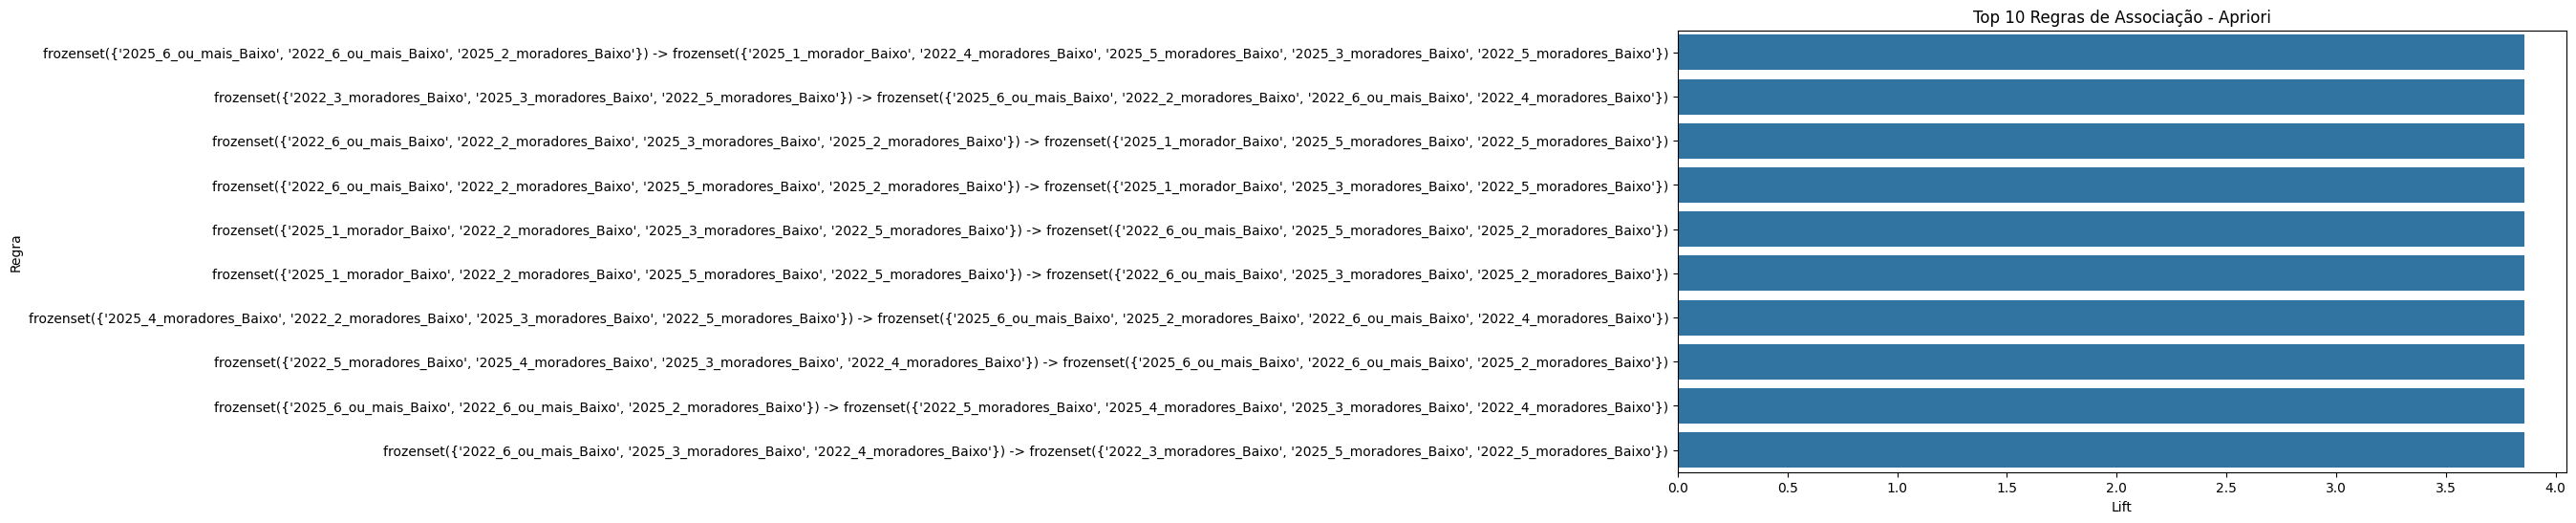

In [26]:
top10_regras = regras.head(10).copy()

top10_regras['regra'] = (
    top10_regras['antecedents'].astype(str) 
    + ' -> ' 
    + top10_regras['consequents'].astype(str)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_regras,
    x='lift',
    y='regra'
)

plt.title('Top 10 Regras de Associação - Apriori')
plt.xlabel('Lift')
plt.ylabel('Regra')

plt.show()